In [1]:
import torch

In [2]:
%env PYTORCH_ENABLE_MPS_FALLBACK=1

env: PYTORCH_ENABLE_MPS_FALLBACK=1


In [20]:
from sklearn.datasets import make_friedman2
from sklearn.gaussian_process.kernels import RBF, ConstantKernel
from sklearn.gaussian_process import GaussianProcessRegressor
import numpy as np
import time
X, y = make_friedman2(n_samples=10, noise=0, random_state=0)
kernel1 = RBF(0.5)
start = time.time()
gpr1 = GaussianProcessRegressor(kernel1,optimizer=None,alpha=0.1).fit(X, y)
y_pred1, y_cov1 = gpr1.predict(X[:2,:], return_cov=True)
print(time.time()-start)
y_pred1, y_cov1

0.004179954528808594


(array([710.83132518, 471.31194159]),
 array([[0.09090909, 0.        ],
        [0.        , 0.09090909]]))

In [21]:
from kernels import rbf
from _gp import gpr
import utils

In [25]:
kernel2 = rbf(0.5, 1)
start = time.time()
gpr2 = gpr(kernel2,0.1).fit(X,y)
y_pred2, y_cov2 = gpr2.predict(X[:2,:])
print(time.time()-start)
y_pred2, y_cov2

0.00279998779296875


(tensor([[710.8313],
         [471.3119]], dtype=torch.float64),
 tensor([[0.0909, 0.0000],
         [0.0000, 0.0909]], dtype=torch.float64))

## Kernel comparison

In [1]:
from sklearn.datasets import make_friedman2
from scipy.spatial.distance import cdist, pdist, squareform
import utils

X, y = make_friedman2(n_samples=5, noise=0, random_state=0)
Xt = utils.numpyToTorch(X)

print(X)
print(Xt)

[[5.48813504e+01 1.29401721e+03 6.02763376e-01 6.44883183e+00]
 [4.23654799e+01 1.18081453e+03 4.37587211e-01 9.91773001e+00]
 [9.63662761e+01 7.52064577e+02 7.91725038e-01 6.28894920e+00]
 [5.68044561e+01 1.63774446e+03 7.10360582e-02 1.87129300e+00]
 [2.02183974e+00 1.48585495e+03 7.78156751e-01 9.70012148e+00]]
tensor([[5.4881e+01, 1.2940e+03, 6.0276e-01, 6.4488e+00],
        [4.2365e+01, 1.1808e+03, 4.3759e-01, 9.9177e+00],
        [9.6366e+01, 7.5206e+02, 7.9173e-01, 6.2889e+00],
        [5.6804e+01, 1.6377e+03, 7.1036e-02, 1.8713e+00],
        [2.0218e+00, 1.4859e+03, 7.7816e-01, 9.7001e+00]], dtype=torch.float64)


In [2]:
from sklearn.gaussian_process.kernels import RBF
kernel1 = RBF(50)
kernel1(X,eval_gradient=True)

(array([[1.00000000e+00, 7.45182814e-02, 2.18249607e-26, 5.43992211e-11,
         3.62933986e-04],
        [7.45182814e-02, 1.00000000e+00, 6.00604288e-17, 6.94104533e-19,
         5.97617019e-09],
        [2.18249607e-26, 6.00604288e-17, 1.00000000e+00, 5.34182071e-69,
         2.86314472e-48],
        [5.43992211e-11, 6.94104533e-19, 5.34182071e-69, 1.00000000e+00,
         5.37138389e-03],
        [3.62933986e-04, 5.97617019e-09, 2.86314472e-48, 5.37138389e-03,
         1.00000000e+00]]),
 array([[[0.00000000e+00],
         [3.87004852e-01],
         [2.57913170e-24],
         [2.57141542e-09],
         [5.74981042e-03]],
 
        [[3.87004852e-01],
         [0.00000000e+00],
         [4.48665583e-15],
         [5.80433315e-17],
         [2.26323373e-07]],
 
        [[2.57913170e-24],
         [4.48665583e-15],
         [0.00000000e+00],
         [1.67949840e-66],
         [6.26869296e-46]],
 
        [[2.57141542e-09],
         [5.80433315e-17],
         [1.67949840e-66],
        

In [3]:
from kernels import rbf
kernel2 = rbf(50, 1)
kernel2(X,grad=True)

(tensor([[1.0000e+00, 7.4518e-02, 2.1825e-26, 5.4399e-11, 3.6293e-04],
         [7.4518e-02, 1.0000e+00, 6.0060e-17, 6.9410e-19, 5.9762e-09],
         [2.1825e-26, 6.0060e-17, 1.0000e+00, 5.3418e-69, 2.8631e-48],
         [5.4399e-11, 6.9410e-19, 5.3418e-69, 1.0000e+00, 5.3714e-03],
         [3.6293e-04, 5.9762e-09, 2.8631e-48, 5.3714e-03, 1.0000e+00]],
        dtype=torch.float64),
 tensor([[[0.0000e+00],
          [3.8700e-01],
          [2.5791e-24],
          [2.5714e-09],
          [5.7498e-03]],
 
         [[3.8700e-01],
          [0.0000e+00],
          [4.4867e-15],
          [5.8043e-17],
          [2.2632e-07]],
 
         [[2.5791e-24],
          [4.4867e-15],
          [0.0000e+00],
          [1.6795e-66],
          [6.2687e-46]],
 
         [[2.5714e-09],
          [5.8043e-17],
          [1.6795e-66],
          [0.0000e+00],
          [5.6149e-02]],
 
         [[5.7498e-03],
          [2.2632e-07],
          [6.2687e-46],
          [5.6149e-02],
          [0.0000e+00]]], 

In [21]:
import torch

dists = pdist(X / 50, metric="sqeuclidean")
distst = torch.pdist(Xt/50)**2

print(dists)
print(distst)

[  5.19342159 118.17348642  47.26934256  15.84257919  74.70236094
  83.62332876  37.87097182 314.40560973 218.94432778  10.45333939]
tensor([  5.1934, 118.1735,  47.2693,  15.8426,  74.7024,  83.6233,  37.8710,
        314.4056, 218.9443,  10.4533], dtype=torch.float64)


In [22]:
import numpy as np

K = np.exp(-0.5 * dists)
Kt = torch.exp(-0.5*distst)

print(K)
print(Kt)

[7.45182814e-02 2.18249607e-26 5.43992211e-11 3.62933986e-04
 6.00604288e-17 6.94104533e-19 5.97617019e-09 5.34182071e-69
 2.86314472e-48 5.37138389e-03]
tensor([7.4518e-02, 2.1825e-26, 5.4399e-11, 3.6293e-04, 6.0060e-17, 6.9410e-19,
        5.9762e-09, 5.3418e-69, 2.8631e-48, 5.3714e-03], dtype=torch.float64)


In [23]:
K = squareform(K)
np.fill_diagonal(K, 1)
Kt = utils.torch_squareform(Kt)
Kt.fill_diagonal_(1)

print(K)
print(Kt)

[[1.00000000e+00 7.45182814e-02 2.18249607e-26 5.43992211e-11
  3.62933986e-04]
 [7.45182814e-02 1.00000000e+00 6.00604288e-17 6.94104533e-19
  5.97617019e-09]
 [2.18249607e-26 6.00604288e-17 1.00000000e+00 5.34182071e-69
  2.86314472e-48]
 [5.43992211e-11 6.94104533e-19 5.34182071e-69 1.00000000e+00
  5.37138389e-03]
 [3.62933986e-04 5.97617019e-09 2.86314472e-48 5.37138389e-03
  1.00000000e+00]]
tensor([[1.0000e+00, 7.4518e-02, 2.1825e-26, 5.4399e-11, 3.6293e-04],
        [7.4518e-02, 1.0000e+00, 6.0060e-17, 6.9410e-19, 5.9762e-09],
        [2.1825e-26, 6.0060e-17, 1.0000e+00, 5.3418e-69, 2.8631e-48],
        [5.4399e-11, 6.9410e-19, 5.3418e-69, 1.0000e+00, 5.3714e-03],
        [3.6293e-04, 5.9762e-09, 2.8631e-48, 5.3714e-03, 1.0000e+00]],
       dtype=torch.float64)


In [24]:
K_gradient = (K * squareform(dists))[:, :, np.newaxis]
K_gradientt = (Kt*utils.torch_squareform(distst))[:, :, None]

print(K_gradient)
print(K_gradientt)

[[[0.00000000e+00]
  [3.87004852e-01]
  [2.57913170e-24]
  [2.57141542e-09]
  [5.74981042e-03]]

 [[3.87004852e-01]
  [0.00000000e+00]
  [4.48665583e-15]
  [5.80433315e-17]
  [2.26323373e-07]]

 [[2.57913170e-24]
  [4.48665583e-15]
  [0.00000000e+00]
  [1.67949840e-66]
  [6.26869296e-46]]

 [[2.57141542e-09]
  [5.80433315e-17]
  [1.67949840e-66]
  [0.00000000e+00]
  [5.61488988e-02]]

 [[5.74981042e-03]
  [2.26323373e-07]
  [6.26869296e-46]
  [5.61488988e-02]
  [0.00000000e+00]]]
tensor([[[0.0000e+00],
         [3.8700e-01],
         [2.5791e-24],
         [2.5714e-09],
         [5.7498e-03]],

        [[3.8700e-01],
         [0.0000e+00],
         [4.4867e-15],
         [5.8043e-17],
         [2.2632e-07]],

        [[2.5791e-24],
         [4.4867e-15],
         [0.0000e+00],
         [1.6795e-66],
         [6.2687e-46]],

        [[2.5714e-09],
         [5.8043e-17],
         [1.6795e-66],
         [0.0000e+00],
         [5.6149e-02]],

        [[5.7498e-03],
         [2.2632e-07],
 

## HETGPY Test

In [1]:
from hetgpy import homGP
import numpy as np
import matplotlib.pyplot as plt

xgrid = np.linspace(0,2*np.pi, 100).reshape(-1,1)
xs    = xgrid.squeeze() # for plotting

X = np.linspace(0,2*np.pi, 10).reshape(-1,1)
Z = np.sin(X).squeeze()

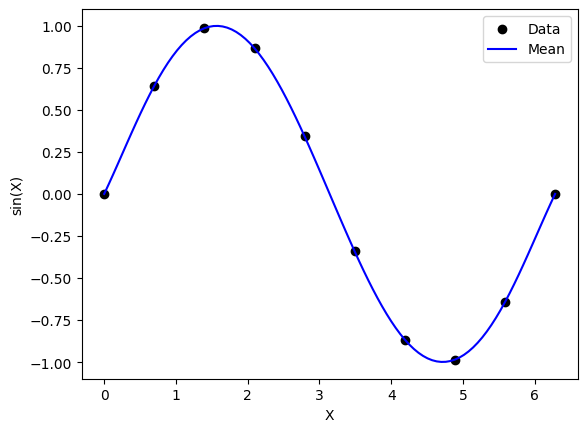

In [2]:
fig, ax = plt.subplots()
ax.scatter(X, Z, color = 'k', label = 'Data')
ax.legend(edgecolor='black')
ax.set_xlabel('X'); ax.set_ylabel('sin(X)')

GP = homGP()
GP.mle(
    X = X,
    Z = Z,
    covtype = "Gaussian",
    lower = np.array([0.1]),
    upper = np.array([2.0])
)
preds = GP.predict(x = xgrid)
ax.plot(xs, preds['mean'], color = 'blue', label = 'Mean')
ax.legend();